# 04 — Búsqueda de hiperparámetros: red neuronal (MLP)

Un MLP feed-forward (PyTorch). Buscamos arquitectura y **regularización**:

- Arquitectura: `hidden_dims` (capas y anchos).
- Regularización: `dropout`, `weight_decay` (L2 vía el optimizador). Además, cada
  modelo hace *early stopping* sobre un split interno de validación.
- Optimización: `lr`.

La red estandariza el target internamente. Búsqueda aleatoria con la misma CV
temporal; el test se reserva para el final. (Menos combinaciones que XGBoost porque
cada entrenamiento es más caro.)

**Nota:** con solo unos miles de filas, una red poco regularizada sobreajusta con
ganas (memoriza el rinde medio de cada depto en train y no generaliza al test, que
además cae en años *fuera* del rango de train). Por eso la grilla apunta a redes
chicas y regularización fuerte — el `dropout` alto es el que más mueve la aguja.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import LinearRegressor, XGBoostRegressor, NeuralNetRegressor

# Cultivo del estudio (cambiar a 'maiz' para reproducir con maíz).
CULTIVO = 'soja'
ds = datos.prepare(CULTIVO)
print(f'{CULTIVO}: {len(ds.feature_cols)} features | '
      f'train {ds.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
      f'test {ds.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)
soja: 67 features | train 7551 filas (≤2020) | test 942 filas (≥2021)


## La búsqueda

Búsqueda aleatoria de 14 combinaciones, optimizando RMSE de validación temporal.

In [2]:
grid = {
    'hidden_dims':  [(16,), (32,), (64, 32)],
    'dropout':      [0.1, 0.3, 0.5],
    'weight_decay': [1e-3, 1e-2, 3e-2],
    'lr':           [1e-3, 3e-3],
}
tabla, best = ev.buscar(NeuralNetRegressor, grid, ds, metric='rmse',
                        n_iter=14, random_state=42, n_splits=4,
                        fixed={'max_epochs': 200, 'patience': 25, 'l1_lambda': 0.0})
print('Mejores hiperparámetros:', best)
tabla.head(10)

Mejores hiperparámetros: {'hidden_dims': (64, 32), 'dropout': 0.1, 'weight_decay': 0.03, 'lr': 0.003}


,hidden_dims,dropout,weight_decay,lr,cv_rmse,cv_rmse_std
0,"(64, 32)",0.100,0.030,0.003,639.952,102.899
1,"(32,)",0.500,0.010,0.003,642.138,103.171
2,"(32,)",0.300,0.030,0.001,659.336,94.427
3,"(32,)",0.500,0.010,0.001,664.220,106.933
4,"(16,)",0.100,0.030,0.001,670.140,102.642
5,"(16,)",0.300,0.010,0.003,695.560,133.543
6,"(64, 32)",0.500,0.001,0.003,697.804,177.581
7,"(32,)",0.300,0.010,0.001,700.815,117.054
8,"(64, 32)",0.500,0.010,0.001,705.587,169.153
9,"(16,)",0.100,0.010,0.003,709.773,118.591


## Modelo final

Reentrenamos con los mejores hiperparámetros sobre todo el train y evaluamos en el
test. **Métricas del modelo final:**

In [3]:
modelo = NeuralNetRegressor(**best, l1_lambda=0.0, max_epochs=250, patience=30,
                            random_state=42).fit(ds.X_train, ds.y_train)
pred = modelo.predict(ds.X_test)
ev.tabla([ev.evaluar('Red neuronal (final)', pred, ds),
          ev.evaluar('baseline media x depto', ev.pred_media_depto(ds), ds)])

,modelo,rmse,r2,mae
0,Red neuronal (final),635.614,0.312,489.520
1,baseline media x depto,711.185,0.138,586.187


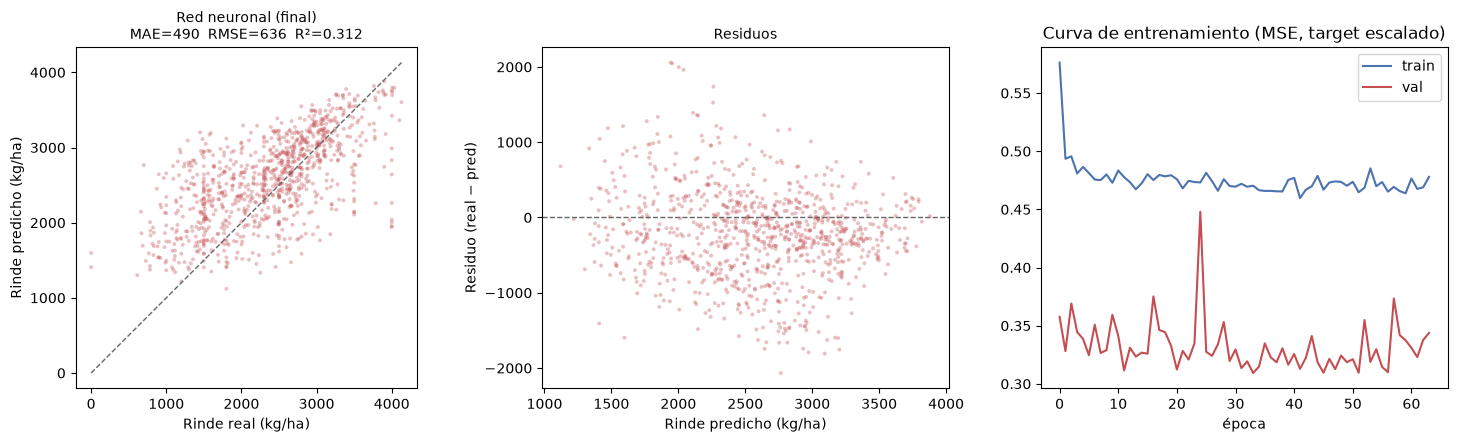

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ev.plot_pred_vs_real(ds.y_test, pred, 'Red neuronal (final)', color=ev.C_NN, ax=axes[0])
ev.plot_residuos(ds.y_test, pred, 'Residuos', color=ev.C_NN, ax=axes[1])
h = modelo.history_
axes[2].plot(h['train_loss'], label='train', color=ev.C_LINEAR)
if h['val_loss']:
    axes[2].plot(h['val_loss'], label='val', color=ev.C_NN)
axes[2].set_title('Curva de entrenamiento (MSE, target escalado)')
axes[2].set_xlabel('época'); axes[2].legend()
plt.tight_layout(); plt.show()

## El mejor modelo del Componente A como features

Con la **configuración final ya elegida**, evaluamos en test el dataset (único,
unificado: clima + NDVI + ERA5) contra tres estrategias que reusan el **mejor
detector del Componente A** (el VAE `recon_prob`, que aprendió a representar el
clima "normal"): concatenar su **espacio latente**, hacer la regresión **solo en
el latente**, y agregar la categórica **`es_anomalo`** (su score umbralado).

El latente/score se computan en `latente.py` (y se cachean). *La primera corrida
entrena el VAE, así que tarda unos minutos.*

In [5]:
tabla_lat = ev.comparar_latente(
    NeuralNetRegressor, best, CULTIVO, fixed=dict(l1_lambda=0.0, max_epochs=250, patience=30, random_state=42),
    vae_kwargs=dict(score_seeds=(42, 43, 44)))
tabla_lat

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,83,479.010,597.466,0.392,26.107,22.371
1,+ es_anomalo,68,487.210,622.609,0.340,27.287,22.813
2,dataset unificado,67,489.520,635.614,0.312,27.466,22.726
3,solo latente,16,775.097,932.174,-0.480,35.058,35.841


## Conclusión

Con tan pocos miles de filas y features tabulares, la red neuronal compite pero no
suele destronar a un XGBoost bien tuneado. El notebook 05 compara las tres familias
más los baselines en igualdad de condiciones.